# Flow Matching + GRPO: Steering Generative Models with Reinforcement Learning

In this notebook you will:

1. **Train a flow matching model** that maps standard Gaussian noise to a 2D *checkerboard* distribution
2. **Reframe sampling as a sequential decision process** by turning the deterministic ODE into a stochastic SDE
3. **Fine-tune the model with GRPO** with a predefined reward to steer the output distribution toward a reward signal
4. **Play around with your custom reward**
5. **Learn the trade-off** between reward maximization and staying close to the original prior, via KL regularization

This is a mini version of what is done at scale for diffusion/flow-based images, video, or molecules


## 0. Setup

In [ ]:
# Standard imports. PyTorch is the only ML dependency.
import copy
import logging
import numpy as np
import torch
import matplotlib.pyplot as plt
import src

logging.basicConfig(level=logging.INFO, format="%(message)s")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

torch.manual_seed(0)
np.random.seed(0)

SIGMA = 1.5
STEP_NUMBER=100

Using device: cpu


## 1. Training a flow matching model

### 1.1 The data: a 2D checkerboard

Our target distribution is a 2D checkerboard:

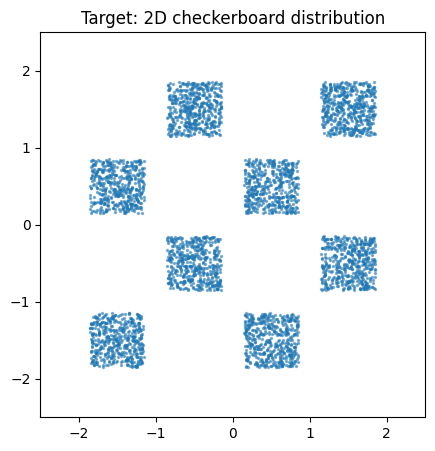

In [2]:
points = src.sample_checkerboard(4000)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.5)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
ax.set_aspect("equal")
ax.set_title("Target: 2D checkerboard distribution")
plt.show()

### 1.2 Train the velocity field

We regress the velocity network $u^\theta_t(x_t)$ on the per-pair conditional target $x_1 - x_0$ along the straight-line path $x_t = (1 - t)\, x_0 + t\, x_1$. Minimising $\mathbb{E}\,\|u^\theta_t(x_t) - (x_1 - x_0)\|^2$ recovers the marginal velocity field that transports noise to data:

In [3]:
print("Training base flow matching model...")
base_model, losses = src.train_flow_matching(steps=4000, device=device)
print("Done.")

Training base flow matching model...


  step 0: loss 2.2227
  step 500: loss 1.6671
  step 1000: loss 1.7252
  step 1500: loss 1.7196
  step 2000: loss 1.6795
  step 2500: loss 1.6682
  step 3000: loss 1.5502
  step 3500: loss 1.6247


Done.


### 1.3 Sampling: integrate the ODE

With $u^\theta_t$ trained, we draw a sample by integrating $\dot x = u^\theta_t(x)$ from $t = 0$ (pure noise) to $t = 1$ (data) 

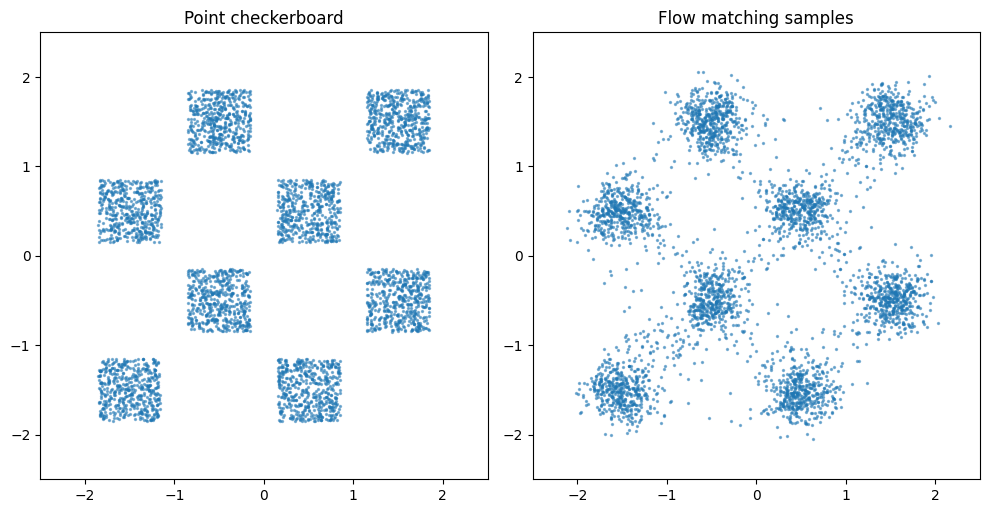

In [4]:
samples = src.sample_ode(base_model, n=4000, step_number=100)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(points[:, 0], points[:, 1], s=2, alpha=0.5)
axes[0].set_title("Point checkerboard")
axes[1].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.5)
axes[1].set_title("Flow matching samples")

for ax in axes:
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect("equal")
    
plt.tight_layout(); plt.show()

**You should see** 8 visible modes in the right plot, roughly arranged in a checkerboard. The boundaries are softer than the true distribution, that is expected from a 4-layer MLP trained. For a teaching notebook this is fine; the point of the next sections is *not* density estimation quality but the RL fine-tuning that comes next.

---

## 2. From flow to policy: the deterministic-to-stochastic move

Right now our flow is **deterministic**: given the same $x_0$ and the same network, you always get the same $x_1$. There is nothing to "explore." To do RL, we need a *stochastic* policy that we can sample from and compute log-probs for.

### The fix: replace the ODE with an SDE

We discretize $[0, 1]$ into $K$ steps with $\Delta t = 1/K$. Instead of the deterministic update

$$x_{k+1} = x_k + u^\theta_{t_k}(x_k)\, \Delta t$$

we sample

$$x_{k+1} \sim \mathcal{N}\!\left(x_k + u^\theta_{t_k}(x_k)\, \Delta t,\; \sigma^2 \Delta t \cdot I\right)$$

This is **Euler-Maruyama integration** of the SDE

$$dx = u^\theta_t(x)\, dt + \sigma\, dW$$

In the limit $\sigma \to 0$ we recover the original deterministic flow; for $\sigma > 0$ we have a genuine stochastic policy whose log-probability under the model is tractable (it's a product of Gaussians).

### What this means in RL terms

- **Trajectory**: $\tau = (x_0, x_1, \ldots, x_K)$.
- **Policy log-prob**: $\log p_\theta(\tau) = \sum_{k=0}^{K-1} \log \mathcal{N}(x_{k+1};\, x_k + u^\theta_{t_k}(x_k)\, \Delta t,\, \sigma^2 \Delta t\, I)$
- **Reward**: a scalar $r(x_K)$ on the final sample only (sparse, terminal).


Quick sanity check: stochastic samples should look similar to deterministic samples (because we picked $\sigma$ small).

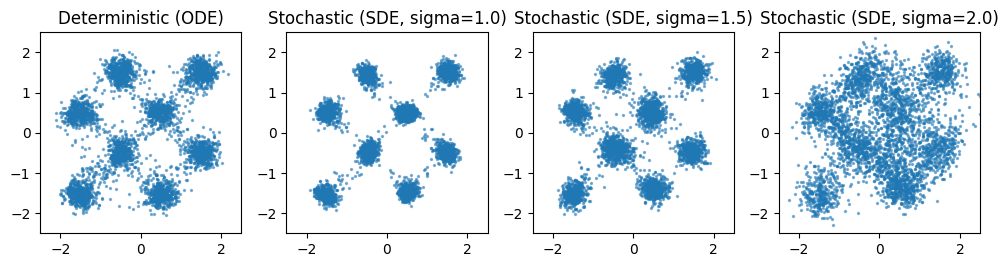

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))

for i, sigma in enumerate([0, 1.0, 1.5, 2.0]):
    if i == 0:
        axes[i].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.5)
        axes[i].set_title("Deterministic (ODE)")
        continue

    with torch.no_grad():
        sto, _, _ = src.rollout(base_model, n=4000, step_number=STEP_NUMBER, sigma=sigma)

    axes[i].scatter(sto.cpu()[:, 0], sto.cpu()[:, 1], s=2, alpha=0.5)
    axes[i].set_title(f"Stochastic (SDE, sigma={sigma})")
    for ax in axes:
        ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

---

## 3. GRPO: steering with a black-box reward

We now have a stochastic policy $\pi_\theta$ that produces final samples $x_K$. We pick a reward function (deliberately a **black box** — it does not need to be differentiable, and we will only ever call it as a function) and fine-tune the policy to maximise expected reward.

### The reward

For the first experiment we reward the policy for landing in *either* the top-right square $[1, 2]^2$ or the bottom-left square $[-2, -1]^2$ of the checkerboard:

$$r(x) = \mathbb{1}\!\left[x \in [1, 2]^2 \cup [-2, -1]^2\right] \in \{0, 1\}$$

Note two things:
- The reward is **sparse and non-differentiable**: 1 inside the target squares, 0 elsewhere. There is no gradient signal to exploit, only a yes/no answer per sample.
- The high-reward set is **disconnected**, so the policy has to discover and hold mass at *two* well-separated modes simultaneously.

### The KL estimator

Every Euler step of the marginal-preserving SDE has Gaussian transitions $\pi(X_{t+h}\mid X_t) = \mathcal{N}(X_t + h\, b_t(X_t),\ \sigma^2 h\, I)$, with the **score-corrected drift**

$$b_t(x) \;=\; u^\theta_t(x) \;+\; \frac{\sigma^2}{2(1-t)}\bigl(t\, u^\theta_t(x) - x\bigr).$$

The covariance is the same under $\pi_\theta$ and $\pi_{\mathrm{ref}}$, so the trajectory-level KL has a **closed form** — no Monte-Carlo estimator needed. The $-x$ piece of the score correction cancels in $\mu_\theta - \mu_{\mathrm{ref}}$, leaving a time-dependent weight $C_{t_k}^2$ on the squared velocity residual:

$$\mathrm{KL}(\pi_\theta \| \pi_{\mathrm{ref}}) \;=\; \sum_{k=0}^{K-1} \frac{h\, C_{t_k}^2}{2\sigma^2}\,\bigl\| u^\theta_{t_k}(X_{t_k}) - u^{\mathrm{ref}}_{t_k}(X_{t_k}) \bigr\|^2,
\qquad C_t \;=\; 1 + \frac{t\,\sigma^2}{2(1-t)}.$$

This is what `src.kl_to_ref_gaussian` computes. It is exact (not an estimator), deterministic given the trajectory.

In [6]:
def two_squares_reward(points: torch.Tensor) -> torch.Tensor:
    """1.0 inside the top-right or bottom-left unit square of the checkerboard, else 0.0."""
    x, y = points[:, 0], points[:, 1]

    top_right   = (x >= 1) & (x < 2) & (y >= 1) & (y < 2)
    bottom_left = (x >= -2) & (x < -1) & (y >= -2) & (y < -1)
    
    return (top_right | bottom_left).float()

Because we run GRPO against several different rewards in the rest of the notebook (the two-squares reward here, a per-square triangle reward in Section 4, a sweep over `kl_coef` in Section 5), we wrap the boilerplate in a few small helpers:

In [7]:
from matplotlib.patches import Rectangle


def run_grpo(reward_func, base_model, step_number, sigma, **kwargs):
    """Fine-tune a fresh copy of `base_model` against `reward_func` with GRPO.

    Returns (policy, history). Extra kwargs are forwarded to src.grpo_train.
    """
    ref_model = copy.deepcopy(base_model)
    for p in ref_model.parameters():
        p.requires_grad_(False)
    policy = copy.deepcopy(base_model)
    history = src.grpo_train(policy, ref_model, step_number= step_number, sigma=sigma,reward_func=reward_func, **kwargs)
    return policy, history


def mark_reward_squares(ax):
    """Outline the two_squares_reward target regions."""
    for (x0, y0) in [(1, 1), (-2, -2)]:
        ax.add_patch(Rectangle((x0, y0), 1, 1, fill=False,
                               edgecolor="purple", linewidth=2, linestyle="--"))


def plot_samples(ax, samples, title, overlay=None, color=None):
    """Scatter `samples` on `ax`, then call `overlay(ax)` if given (reward annotations)."""
    scatter_kwargs = {"s": 2, "alpha": 0.5}
    if color is not None:
        scatter_kwargs["color"] = color
    ax.scatter(samples[:, 0], samples[:, 1], **scatter_kwargs)
    if overlay is not None:
        overlay(ax)
    ax.set_title(title)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect("equal")

### 3.1 Running GRPO

In [8]:
print("Running GRPO with the two-squares reward...")
policy, history = run_grpo(two_squares_reward, base_model, iters=150, kl_coef=0.15, step_number=STEP_NUMBER, sigma=SIGMA)
print("Done.")

iter   0: reward 0.297  KL 0.109  pg_loss 0.0008


Running GRPO with the two-squares reward...


iter  20: reward 0.438  KL 0.767  pg_loss -0.0062
iter  40: reward 0.531  KL 1.184  pg_loss -0.0166
iter  60: reward 0.688  KL 1.622  pg_loss -0.0265
iter  80: reward 0.828  KL 3.588  pg_loss -0.0100
iter 100: reward 0.891  KL 1.888  pg_loss -0.0132
iter 120: reward 0.969  KL 2.267  pg_loss -0.0100
iter 140: reward 0.969  KL 2.305  pg_loss -0.0182


Done.


### 3.2 Before vs. after

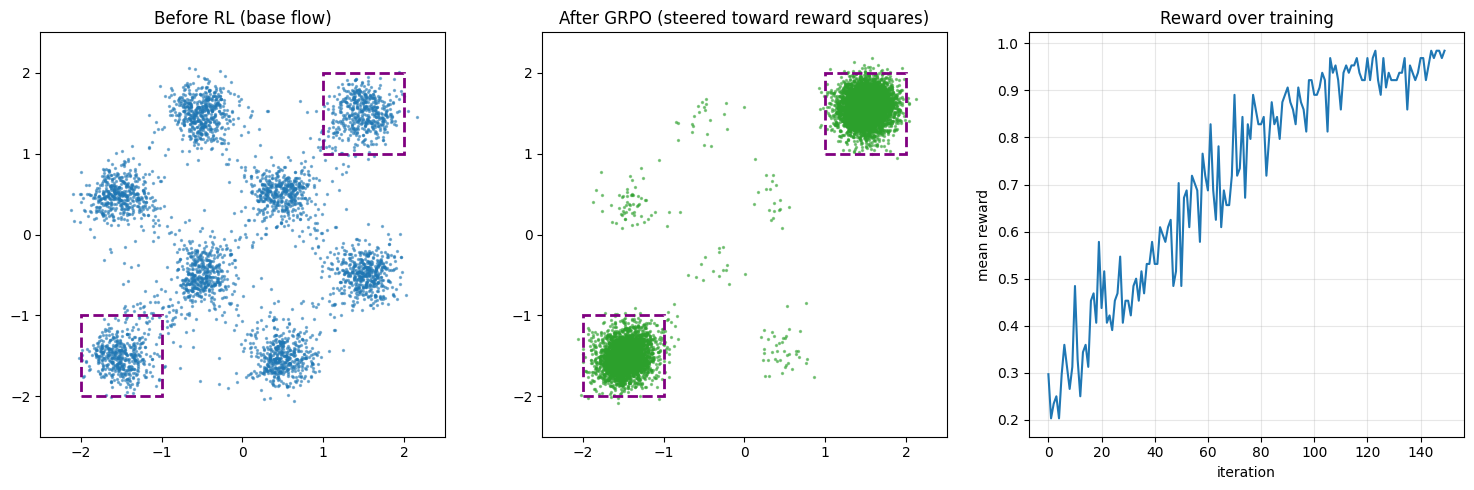

In [9]:
with torch.no_grad():
    after, _, _ = src.rollout(policy, n=8000, step_number=STEP_NUMBER, sigma=SIGMA)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_samples(axes[0], samples, "Before RL (base flow)", overlay=mark_reward_squares)
plot_samples(axes[1], after.cpu(), "After GRPO (steered toward reward squares)",
             overlay=mark_reward_squares, color="C2")

axes[2].plot(history["reward"])
axes[2].set_xlabel("iteration"); axes[2].set_ylabel("mean reward")
axes[2].set_title("Reward over training")
axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**What just happened.** GRPO concentrated mass inside the two reward squares without ever differentiating through the reward function. It only called `two_squares_reward` on samples and used the resulting scalars to weight policy gradient steps. In particular, the reward was a sparse $\{0, 1\}$ indicator with no gradient information to exploit, yet the policy still moved.

If you look closely, the post-GRPO distribution **still has some structure from the original checkerboard**. There is residual mass at the other modes. That's the KL term keeping the policy close to the prior. If we set `kl_coef` to 0, the more aggressive concentration should be seen. We will study that trade-off in Section 5


### 3.3 Design your own reward

The reward is the only thing connecting the policy to the task. Try defining your own `my_reward` below and re-running GRPO to see how the post-RL distribution changes.

A few ideas, roughly in order of difficulty:

While you experiment, keep an eye on:

- How fast `mean reward` grows with iterations
- Whether all the desired modes survive or only the most accessible one wins
- Whether the post-training samples stay inside the high-reward gegions or some end up oustide of them. When points are outside, it means `kl_coef` is too high

In [10]:
def my_reward(points: torch.Tensor) -> torch.Tensor:
    return torch.ones(points.shape[0], device=points.device)  # Constant reward of 1.0 for all points.

policy_custom, hist_custom = run_grpo(
    my_reward, base_model,
    iters=100, kl_coef=0.05, log_every=20, step_number=STEP_NUMBER, sigma=SIGMA
)

iter   0: reward 1.000  KL 0.000  pg_loss -0.0000
iter  20: reward 1.000  KL 0.000  pg_loss -0.0000
iter  40: reward 1.000  KL 0.000  pg_loss -0.0000
iter  60: reward 1.000  KL 0.000  pg_loss -0.0000
iter  80: reward 1.000  KL 0.000  pg_loss -0.0000


## 4. The KL/reward trade-off

KL regularization controls **how much we are willing to distort the prior in exchange for reward**

In [11]:
kl_coefs = [0.0, 0.25, 0.5]
sweep_results = {}

for kl_coef in kl_coefs:
    print(f"\n=== kl_coef = {kl_coef} ===")
    policy_k, hist_k = run_grpo(
        two_squares_reward, base_model,
        iters=100, kl_coef=kl_coef, log_every=25, step_number=STEP_NUMBER, sigma=SIGMA
    )
    with torch.no_grad():
        samples_k, _, _ = src.rollout(policy_k, n=8000, step_number=STEP_NUMBER, sigma=SIGMA)
    sweep_results[kl_coef] = (samples_k.cpu(), hist_k)

iter   0: reward 0.156  KL 0.073  pg_loss -0.0108



=== kl_coef = 0.0 ===


iter  25: reward 0.562  KL 2.190  pg_loss -0.0340
iter  50: reward 0.828  KL 3.839  pg_loss -0.0513
iter  75: reward 1.000  KL 3.531  pg_loss -0.0000
iter   0: reward 0.219  KL 0.136  pg_loss -0.0299



=== kl_coef = 0.25 ===


iter  25: reward 0.328  KL 0.753  pg_loss -0.0130
iter  50: reward 0.734  KL 1.505  pg_loss -0.0273
iter  75: reward 0.750  KL 1.395  pg_loss -0.0226
iter   0: reward 0.188  KL 0.040  pg_loss -0.0359



=== kl_coef = 0.5 ===


iter  25: reward 0.359  KL 0.487  pg_loss -0.0308
iter  50: reward 0.641  KL 0.526  pg_loss -0.0113
iter  75: reward 0.656  KL 0.977  pg_loss -0.0244


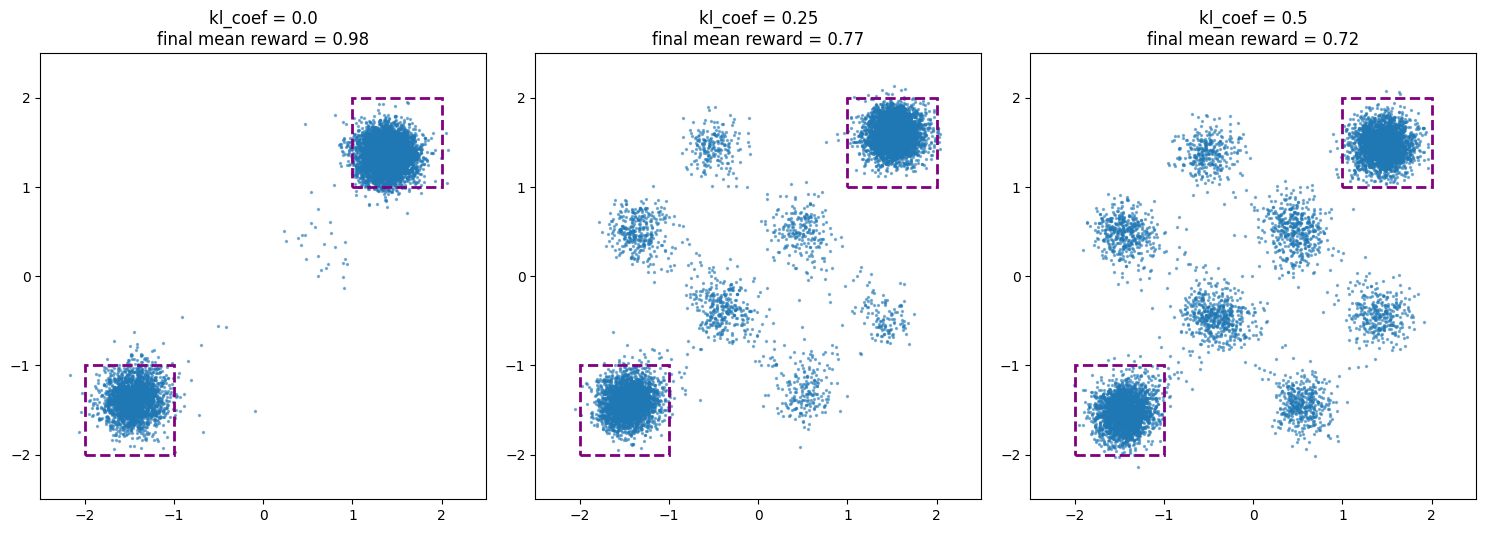

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, kl_coef in zip(axes, kl_coefs):
    s, h = sweep_results[kl_coef]
    plot_samples(ax, s,
                 f"kl_coef = {kl_coef}\nfinal mean reward = {h['reward'][-1]:.2f}",
                 overlay=mark_reward_squares)
plt.tight_layout(); plt.show()

**Read the plots left-to-right:**

- **`kl_coef = 0` (no regularization)**: the policy is free to do whatever maximizes reward. Expect aggressive collapse onto the target — at the cost of forgetting the checkerboard prior entirely.
- **`kl_coef = 0.05` (light regularization)**: a clear shift toward the target, but the original modes are still visible. This is roughly the regime used in RLHF.
- **`kl_coef = 0.5` (heavy regularization)**: the policy barely moves. The KL term dominates; reward gain is small.

This is **the central trade-off of RL fine-tuning of generative models**. Too little KL, mode collapse, loss of diversity. Too much KL, the reward signal is ignored. Choosing the right coefficient is one of the main practical decisions.


1. **Flow matching** is a simple, clean way to train generative models: regress a velocity field along straight-line paths between noise and data.
2. **Turning a generative model into an RL policy** requires only one structural change: replace the deterministic ODE with a stochastic SDE so trajectories have tractable log-probs.
3. **KL regularization** controls the trade-off between reward maximization and staying close to the prior. This is the central knob in modern RLHF.
4. The whole picture — generative prior + RL fine-tuning + KL-to-reference — is the **shared template** behind RLHF for LLMs, diffusion/flow RL for images and video, and modern robotics policies.